In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


# Teste com Petrobras (PETR4)
ticker = yf.Ticker("PETR4.SA")

# Puxando o histórico dos últimos 5 anos
historico = ticker.history(period="5y")
historico.describe()




,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1247.000000,1247.000000,1247.000000,1247.000000,1.247000e+03,1247.000000,1247.0
mean,23.909965,24.198235,23.635095,23.922291,5.345013e+07,0.031825,0.0
std,10.009196,10.097528,9.932259,10.019005,3.135939e+07,0.299942,0.0
min,7.121190,7.289757,7.035429,7.289757,9.356900e+06,0.000000,0.0
25%,13.827779,14.083165,13.597946,13.822456,3.115360e+07,0.000000,0.0
50%,26.630784,26.967428,26.237094,26.656397,4.605470e+07,0.000000,0.0
75%,29.372547,29.556644,29.088613,29.331317,6.685150e+07,0.000000,0.0
max,49.939999,50.700001,49.029999,50.430000,3.195016e+08,6.732003,0.0


In [4]:
df = pd.read_csv(r'..\data\processed\roe_2021_2025.csv')


In [5]:
import unicodedata

# Dicionário refinado com mapeamento preciso de cada empresa para seu Ticker da B3
REGRAS_TICKERS = {
    'METALURGICA GERDAU': 'GOAU4.SA',
    'GERDAU': 'GGBR4.SA',
    'CSN MINER': 'CMIN3.SA',
    'SIDERURGICA NACIONAL': 'CSNA3.SA',
    'PETROLEO BRASILEIRO': 'PETR4.SA',
    'VALE': 'VALE3.SA',
    'AMBEV': 'ABEV3.SA',
    'BRADESCO': 'BBDC4.SA',
    'BCO BRASIL': 'BBAS3.SA',
    'SANTANDER': 'SANB11.SA',
    'ITAUSA': 'ITSA4.SA',
    'ITAU': 'ITUB4.SA',
    'WEG': 'WEGE3.SA',
    'COSAN': 'CSAN3.SA',
    'JBS': 'JBSS3.SA',
    'LOCALIZA': 'RENT3.SA',
    'TELEFONICA': 'VIVT3.SA',
    'TIM BRASIL': 'TIMS3.SA',
    'TIM S.A.': 'TIMS3.SA',
    'MAGAZINE LUIZA': 'MGLU3.SA',
    'LOJAS RENNER': 'LREN3.SA',
    'SUZANO': 'SUZB3.SA',
    'KLABIN': 'KLBN11.SA',
    'USIMINAS': 'USIM5.SA',
    'ELETROBRAS': 'ELET3.SA',
    'ENGIE': 'EGIE3.SA',
    'EQUATORIAL': 'EQTL3.SA',
    'CPFL': 'CPFE3.SA',
    'CEMIG': 'CMIG4.SA',
    'COPEL': 'CPLE6.SA',
    'AUREN': 'AURE3.SA',
    'ENERGISA': 'ENGI11.SA',
    'ENEVA': 'ENEV3.SA',
    'NEOENERGIA': 'NEOE3.SA',
    'SANEAMENTO BASICO': 'SBSP3.SA',
    'EMBRAER': 'EMBR3.SA',
    'AZUL': 'AZUL4.SA',
    'GOL LINHAS': 'GOLL4.SA',
    'RUMO': 'RAIL3.SA',
    'VIBRA': 'VBBR3.SA',
    'ULTRAPAR': 'UGPA3.SA',
    'RAIZEN': 'RAIZ4.SA',
    'PRIO': 'PRIO3.SA',
    'BRAVA': 'BRAV3.SA',
    'BRASKEM': 'BRKM5.SA',
    'BRF': 'BRFS3.SA',
    'MARFRIG': 'MRFG3.SA',
    'ATACADAO': 'CRFB3.SA',
    'GRUPO MATEUS': 'GMAT3.SA',
    'DISTRIBUICAO': 'PCAR3.SA',
    'HAPVIDA': 'HAPV3.SA',
    'REDE D\'OR': 'RDOR3.SA',
    'HYPERA': 'HYPE3.SA',
    'B3 S.A.': 'B3SA3.SA',
    'BB SEGURIDADE': 'BBSE3.SA',
    'CAIXA SEGURIDADE': 'CXSE3.SA',
    'PORTO SEGURO': 'PSSA3.SA',
    'RIO GRANDE DO SUL': 'BRSR6.SA',
    'BANRISUL': 'BRSR6.SA',
    'ALLOS': 'ALOS3.SA',
    'BR MALLS': 'ALOS3.SA',
    'ALUPAR': 'ALUP11.SA',
    'CYRELA': 'CYRE3.SA',
    'VIVARA': 'VIVA3.SA',
    'COGNA': 'COGN3.SA',
    'AMERICANAS': 'AMER3.SA',
    'OI S.A.': 'OIBR3.SA',
    'CIELO': 'CIEL3.SA',
    'PETTENATI': 'PTNT4.SA',
    'METISA': 'MTSA4.SA',
    'HAGA': 'HAGA4.SA',
    'NATURA': 'NTCO3.SA',
    'ISA ENERGIA': 'TRPL4.SA',
    'EDP': 'ENBR3.SA'
}

In [6]:
# Função que normaliza acentos e mapeia o ticker com precisão
def normalizar_texto(texto):
    return ''.join(c for c in unicodedata.normalize('NFKD', str(texto).upper()) if not unicodedata.combining(c))

def iden_ticker(empresa):
    nome_norm = normalizar_texto(empresa)
    for chave, ticker in REGRAS_TICKERS.items():
        if normalizar_texto(chave) in nome_norm:
            return ticker   
    return None


In [7]:
df['TICKER']= df['DENOM_CIA'].apply(iden_ticker)

In [8]:
df.isnull().sum()


DENOM_CIA          0
SETOR_ATIV         0
ANO_ARQUIVO        0
VL_CONTA_LUCRO     0
VL_CONTA_REAIS     0
VL_CONTA_BI        0
VL_CONTA_PL        0
ROE                0
ROE_ENGANOSO       0
TICKER            65
dtype: int64

In [9]:
df['ROE_ENGANOSO'].value_counts()

ROE_ENGANOSO
False    353
True      31
Name: count, dtype: int64

In [10]:
# 4. Filtrar apenas as empresas listadas em bolsa
df_listadas = df.dropna(subset=['TICKER']).copy()

In [11]:
print(f"Total de registros mapeados: {len(df_listadas)} de {len(df)}")
print(f"Empresas únicas com ações na B3: {df_listadas['TICKER'].nunique()}")

Total de registros mapeados: 319 de 384
Empresas únicas com ações na B3: 70


In [12]:
df_listadas[df_listadas['ROE_ENGANOSO']== True]['DENOM_CIA'].value_counts()

DENOM_CIA
AZUL S.A.                                    5
GOL LINHAS AEREAS INTELIGENTES S.A.          5
HAGA S.A. INDUSTRIA E COMERCIO               5
OI S.A. - EM RECUPERAÇÃO JUDICIAL            3
AMERICANAS S.A. - EM RECUPERAÇÃO JUDICIAL    2
BRASKEM S.A.                                 1
Name: count, dtype: int64

In [13]:
df_listadas = df_listadas[df_listadas['ROE_ENGANOSO'] == False].copy()


In [14]:
df_listadas.drop('ROE_ENGANOSO',axis=1,inplace=True)

In [15]:
df_listadas

,DENOM_CIA,SETOR_ATIV,ANO_ARQUIVO,VL_CONTA_LUCRO,VL_CONTA_REAIS,VL_CONTA_BI,VL_CONTA_PL,ROE,TICKER
0,COSAN S.A.,"Agricultura (Açúcar, Álcool e Cana)",2021,14519180.0,1.451918e+10,14.519180,28870022.0,0.502915,CSAN3.SA
1,JBS S.A.,Alimentos,2021,25184602.0,2.518460e+10,25.184602,47796720.0,0.526911,JBSS3.SA
2,BCO BRADESCO S.A.,Bancos,2021,39414765.0,3.941476e+10,39.414765,150228707.0,0.262365,BBDC4.SA
3,BCO BRASIL S.A.,Bancos,2021,33015754.0,3.301575e+10,33.015754,146110233.0,0.225965,BBAS3.SA
4,BCO SANTANDER (BRASIL) S.A.,Bancos,2021,29010076.0,2.901008e+10,29.010076,105974495.0,0.273746,SANB11.SA
...,...,...,...,...,...,...,...,...,...
378,HAPVIDA PARTICIPAÇÕES E INVESTIMENTOS S.A.,Serviços Médicos,2025,-1583090.0,-1.583090e+09,-1.583090,48250270.0,-0.032810,HAPV3.SA
379,LOCALIZA RENT A CAR S.A.,Serviços Transporte e Logística,2025,7367560.0,7.367560e+09,7.367560,25539012.0,0.288483,RENT3.SA
380,TELEFÔNICA BRASIL S.A,Telecomunicações,2025,11734875.0,1.173488e+10,11.734875,69002726.0,0.170064,VIVT3.SA
381,TIM BRASIL SERVIÇOS E PARTICIPAÇÕES S.A.,Telecomunicações,2025,5800850.0,5.800850e+09,5.800850,19545484.0,0.296787,TIMS3.SA


In [16]:
df_listadas['PL_BI'] = df_listadas['VL_CONTA_PL'] / 1e9  

colunas_uteis = [
    'ANO_ARQUIVO',
    'DENOM_CIA',
    'TICKER',
    'SETOR_ATIV',
    'VL_CONTA_BI',   # Lucro em Bilhões
    'VL_CONTA_PL',   # Patrimônio Líquido BI 
    'ROE'
]

df_listadas = df_listadas[colunas_uteis].copy()




In [17]:
df_listadas.rename(columns={
    'ANO_ARQUIVO': 'ANO',
    'DENOM_CIA': 'EMPRESA',
    'SETOR_ATIV': 'SETOR',
    'VL_CONTA_BI': 'LUCRO_LIQUIDO_BI',
    'VL_CONTA_PL': 'PATRIMONIO_LIQUIDO_BI'
}, inplace=True)


In [18]:
df_listadas.head()

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE
0,2021,COSAN S.A.,CSAN3.SA,"Agricultura (Açúcar, Álcool e Cana)",14.519180,28870022.0,0.502915
1,2021,JBS S.A.,JBSS3.SA,Alimentos,25.184602,47796720.0,0.526911
2,2021,BCO BRADESCO S.A.,BBDC4.SA,Bancos,39.414765,150228707.0,0.262365
3,2021,BCO BRASIL S.A.,BBAS3.SA,Bancos,33.015754,146110233.0,0.225965
4,2021,BCO SANTANDER (BRASIL) S.A.,SANB11.SA,Bancos,29.010076,105974495.0,0.273746


In [19]:
# 1. Pega a lista com o nome dos tickers
tickers = df_listadas['TICKER'].unique().tolist()

# 2. Baixa o preço de fechamento de todos os tickers de 2021 a 2025
dados = yf.download(tickers, start="2021-01-01", end="2025-12-31")['Close']


[***                    6%                       ]  4 of 65 completed$ELET3.SA: possibly delisted; no timezone found
[***                    6%                       ]  4 of 65 completed$PTNT4.SA: possibly delisted; no timezone found
[***********           22%                       ]  14 of 65 completed$CRFB3.SA: possibly delisted; no timezone found
[***********           23%                       ]  15 of 65 completed$ENBR3.SA: possibly delisted; no timezone found
[************          26%                       ]  17 of 65 completed$JBSS3.SA: possibly delisted; no timezone found
[*************         28%                       ]  18 of 65 completed$MRFG3.SA: possibly delisted; no timezone found
[********************  42%                       ]  27 of 65 completed$BRFS3.SA: possibly delisted; no timezone found
[********************* 43%                       ]  28 of 65 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found 

In [20]:
precos_anuais = dados.resample('YE').last()
precos_anuais

Ticker,ABEV3.SA,ALOS3.SA,ALUP11.SA,AMER3.SA,AURE3.SA,B3SA3.SA,BBAS3.SA,BBDC4.SA,BBSE3.SA,BRAV3.SA,...,SUZB3.SA,TIMS3.SA,TRPL4.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VBBR3.SA,VIVA3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2021-12-31,12.240263,16.296768,17.270552,3078.866455,NaN,9.400815,10.175880,12.314574,12.709906,32.446690,...,52.487175,8.982145,NaN,11.790889,13.261773,51.557880,15.326221,23.234751,18.066105,29.563377
2022-12-31,12.133145,13.043149,21.284184,965.000000,11.537799,11.562797,13.733052,10.923213,22.229982,36.508564,...,44.676132,8.875097,NaN,10.671615,6.601693,64.421730,11.700223,20.529127,14.963401,35.136238
2023-12-31,12.072701,20.941452,26.253763,91.000000,12.809960,13.131356,23.825830,13.722247,24.607800,25.817589,...,52.725025,14.583103,NaN,22.908012,8.980270,60.727566,17.829418,31.911589,22.465439,34.223965
2024-12-31,10.891875,15.590858,24.033281,6.200000,8.711704,9.629132,22.537069,9.863410,28.525951,23.377495,...,60.463642,12.587130,NaN,14.062284,5.320000,46.882359,15.021828,18.231518,20.808760,49.804493
2025-12-31,13.821514,26.141726,31.310802,5.130000,11.870000,13.256948,21.423855,17.413023,32.024799,16.737968,...,51.444775,21.050144,NaN,20.298040,5.950000,69.995880,24.666330,33.240002,31.201950,48.292397


In [21]:
df_precos = precos_anuais.stack().reset_index()
df_precos.head()


,Date,Ticker,0
0,2021-12-31,ABEV3.SA,12.240263
1,2021-12-31,ALOS3.SA,16.296768
2,2021-12-31,ALUP11.SA,17.270552
3,2021-12-31,AMER3.SA,3078.866455
4,2021-12-31,AURE3.SA,NaN


In [22]:

df_precos = precos_anuais.stack().reset_index()
coluna_preco = df_precos.columns[-1]
df_precos.rename(columns={
    'Date': 'DATA',
    'Ticker': 'TICKER',
    coluna_preco: 'COTACAO_FINAL_ANO'
}, inplace=True)

df_precos['ANO'] = df_precos['DATA'].dt.year
df_precos.head()

,DATA,TICKER,COTACAO_FINAL_ANO,ANO
0,2021-12-31,ABEV3.SA,12.240263,2021
1,2021-12-31,ALOS3.SA,16.296768,2021
2,2021-12-31,ALUP11.SA,17.270552,2021
3,2021-12-31,AMER3.SA,3078.866455,2021
4,2021-12-31,AURE3.SA,NaN,2021


In [23]:
df_listadas


,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE
0,2021,COSAN S.A.,CSAN3.SA,"Agricultura (Açúcar, Álcool e Cana)",14.519180,28870022.0,0.502915
1,2021,JBS S.A.,JBSS3.SA,Alimentos,25.184602,47796720.0,0.526911
2,2021,BCO BRADESCO S.A.,BBDC4.SA,Bancos,39.414765,150228707.0,0.262365
3,2021,BCO BRASIL S.A.,BBAS3.SA,Bancos,33.015754,146110233.0,0.225965
4,2021,BCO SANTANDER (BRASIL) S.A.,SANB11.SA,Bancos,29.010076,105974495.0,0.273746
...,...,...,...,...,...,...,...
378,2025,HAPVIDA PARTICIPAÇÕES E INVESTIMENTOS S.A.,HAPV3.SA,Serviços Médicos,-1.583090,48250270.0,-0.032810
379,2025,LOCALIZA RENT A CAR S.A.,RENT3.SA,Serviços Transporte e Logística,7.367560,25539012.0,0.288483
380,2025,TELEFÔNICA BRASIL S.A,VIVT3.SA,Telecomunicações,11.734875,69002726.0,0.170064
381,2025,TIM BRASIL SERVIÇOS E PARTICIPAÇÕES S.A.,TIMS3.SA,Telecomunicações,5.800850,19545484.0,0.296787


In [24]:
df_final = pd.merge(df_listadas, df_precos, on=['TICKER', 'ANO'], how='inner')
df_final.head()

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
0,2021,COSAN S.A.,CSAN3.SA,"Agricultura (Açúcar, Álcool e Cana)",14.519180,28870022.0,0.502915,2021-12-31,19.942280
1,2021,JBS S.A.,JBSS3.SA,Alimentos,25.184602,47796720.0,0.526911,2021-12-31,NaN
2,2021,BCO BRADESCO S.A.,BBDC4.SA,Bancos,39.414765,150228707.0,0.262365,2021-12-31,12.314574
3,2021,BCO BRASIL S.A.,BBAS3.SA,Bancos,33.015754,146110233.0,0.225965,2021-12-31,10.175880
4,2021,BCO SANTANDER (BRASIL) S.A.,SANB11.SA,Bancos,29.010076,105974495.0,0.273746,2021-12-31,22.041546


In [25]:
df_final.isnull().sum()

ANO                       0
EMPRESA                   0
TICKER                    0
SETOR                     0
LUCRO_LIQUIDO_BI          0
PATRIMONIO_LIQUIDO_BI     0
ROE                       0
DATA                      0
COTACAO_FINAL_ANO        63
dtype: int64

In [26]:
df_final = df_final.dropna(subset=['COTACAO_FINAL_ANO']).copy()

In [27]:
df_final.isnull().sum()

ANO                      0
EMPRESA                  0
TICKER                   0
SETOR                    0
LUCRO_LIQUIDO_BI         0
PATRIMONIO_LIQUIDO_BI    0
ROE                      0
DATA                     0
COTACAO_FINAL_ANO        0
dtype: int64

In [28]:
df_final.head()

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
0,2021,COSAN S.A.,CSAN3.SA,"Agricultura (Açúcar, Álcool e Cana)",14.519180,28870022.0,0.502915,2021-12-31,19.942280
2,2021,BCO BRADESCO S.A.,BBDC4.SA,Bancos,39.414765,150228707.0,0.262365,2021-12-31,12.314574
3,2021,BCO BRASIL S.A.,BBAS3.SA,Bancos,33.015754,146110233.0,0.225965,2021-12-31,10.175880
4,2021,BCO SANTANDER (BRASIL) S.A.,SANB11.SA,Bancos,29.010076,105974495.0,0.273746,2021-12-31,22.041546
5,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,84017617.0,0.591650,2021-12-31,12.240263


In [29]:
df_final = df_final.reset_index(drop=True)
df_final.head(10)

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
0,2021,COSAN S.A.,CSAN3.SA,"Agricultura (Açúcar, Álcool e Cana)",14.519180,2.887002e+07,0.502915,2021-12-31,19.942280
1,2021,BCO BRADESCO S.A.,BBDC4.SA,Bancos,39.414765,1.502287e+08,0.262365,2021-12-31,12.314574
2,2021,BCO BRASIL S.A.,BBAS3.SA,Bancos,33.015754,1.461102e+08,0.225965,2021-12-31,10.175880
3,2021,BCO SANTANDER (BRASIL) S.A.,SANB11.SA,Bancos,29.010076,1.059745e+08,0.273746,2021-12-31,22.041546
4,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,8.401762e+07,0.591650,2021-12-31,12.240263
5,2021,"B3 S.A. - BRASIL, BOLSA, BALCÃO",B3SA3.SA,Bolsas de Valores/Mercadorias e Futuros,17.735608,2.241937e+07,0.791084,2021-12-31,9.400815
6,2021,VIVARA PARTICIPAÇÕES S.A.,VIVA3.SA,Comércio (Atacado e Varejo),445.162380,1.392731e+09,0.319633,2021-12-31,23.234751
7,2021,VIBRA ENERGIA S/A,VBBR3.SA,Comércio (Atacado e Varejo),12.804000,1.230800e+07,1.040299,2021-12-31,15.326221
8,2021,CIA BRASILEIRA DE DISTRIBUICAO,PCAR3.SA,Comércio (Atacado e Varejo),6.572000,1.638000e+07,0.401221,2021-12-31,21.408865
9,2021,MAGAZINE LUIZA S.A.,MGLU3.SA,Comércio (Atacado e Varejo),0.982370,1.126123e+07,0.087235,2021-12-31,61.854729


In [30]:
df_final.value_counts()

ANO   EMPRESA                                     TICKER     SETOR                                LUCRO_LIQUIDO_BI  PATRIMONIO_LIQUIDO_BI  ROE        DATA        COTACAO_FINAL_ANO
2021  COSAN S.A.                                  CSAN3.SA   Agricultura (Açúcar, Álcool e Cana)   14.519180        28870022.0              0.502915  2021-12-31  19.942280            1
      BCO BRADESCO S.A.                           BBDC4.SA   Bancos                                39.414765        150228707.0             0.262365  2021-12-31  12.314574            1
      BCO BRASIL S.A.                             BBAS3.SA   Bancos                                33.015754        146110233.0             0.225965  2021-12-31  10.175880            1
      BCO SANTANDER (BRASIL) S.A.                 SANB11.SA  Bancos                                29.010076        105974495.0             0.273746  2021-12-31  22.041546            1
      AMBEV S.A.                                  ABEV3.SA   Bebidas e Fumo     

In [31]:
import seaborn as sns 

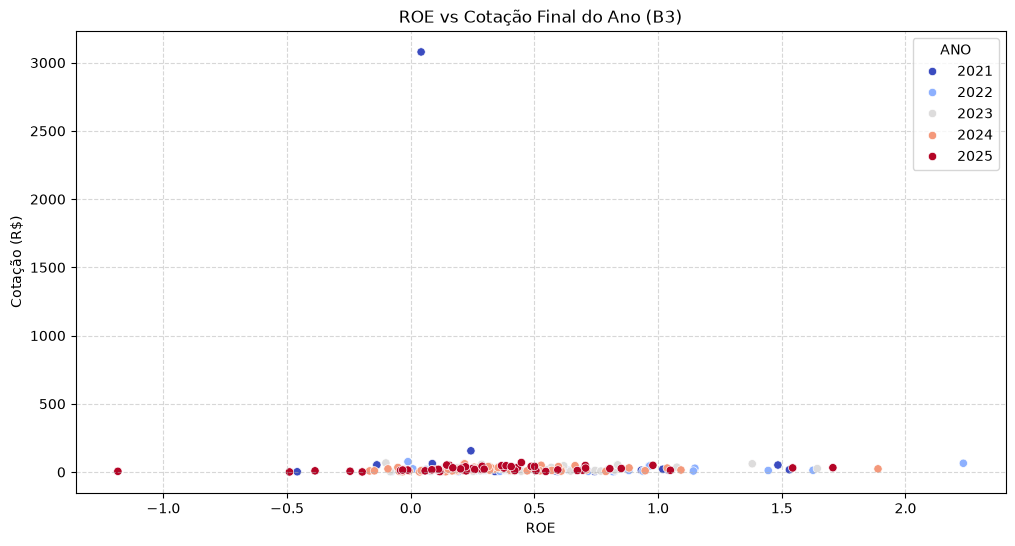

In [32]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_final,x='ROE',y='COTACAO_FINAL_ANO',hue='ANO',palette='coolwarm')
plt.title('ROE vs Cotação Final do Ano (B3)')
plt.xlabel('ROE')
plt.ylabel('Cotação (R$)')
plt.grid(True, linestyle='--', alpha=0.5)




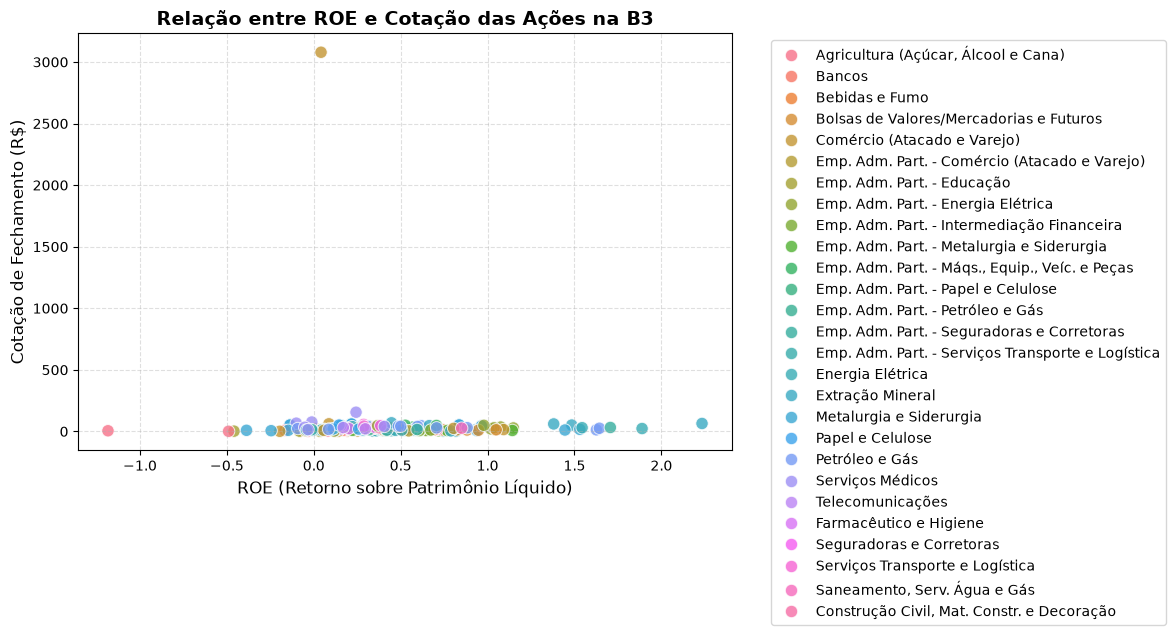

In [33]:
# Gráfico de Dispersão: ROE vs Cotação Final do Ano
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_final,
    x='ROE',
    y='COTACAO_FINAL_ANO',
    hue='SETOR',
    alpha=0.8,
    s=80
)

plt.title('Relação entre ROE e Cotação das Ações na B3', fontsize=14, fontweight='bold')
plt.xlabel('ROE (Retorno sobre Patrimônio Líquido)', fontsize=12)
plt.ylabel('Cotação de Fechamento (R$)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_15468\3397724192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='SETOR', y='ROE', palette='Set2')


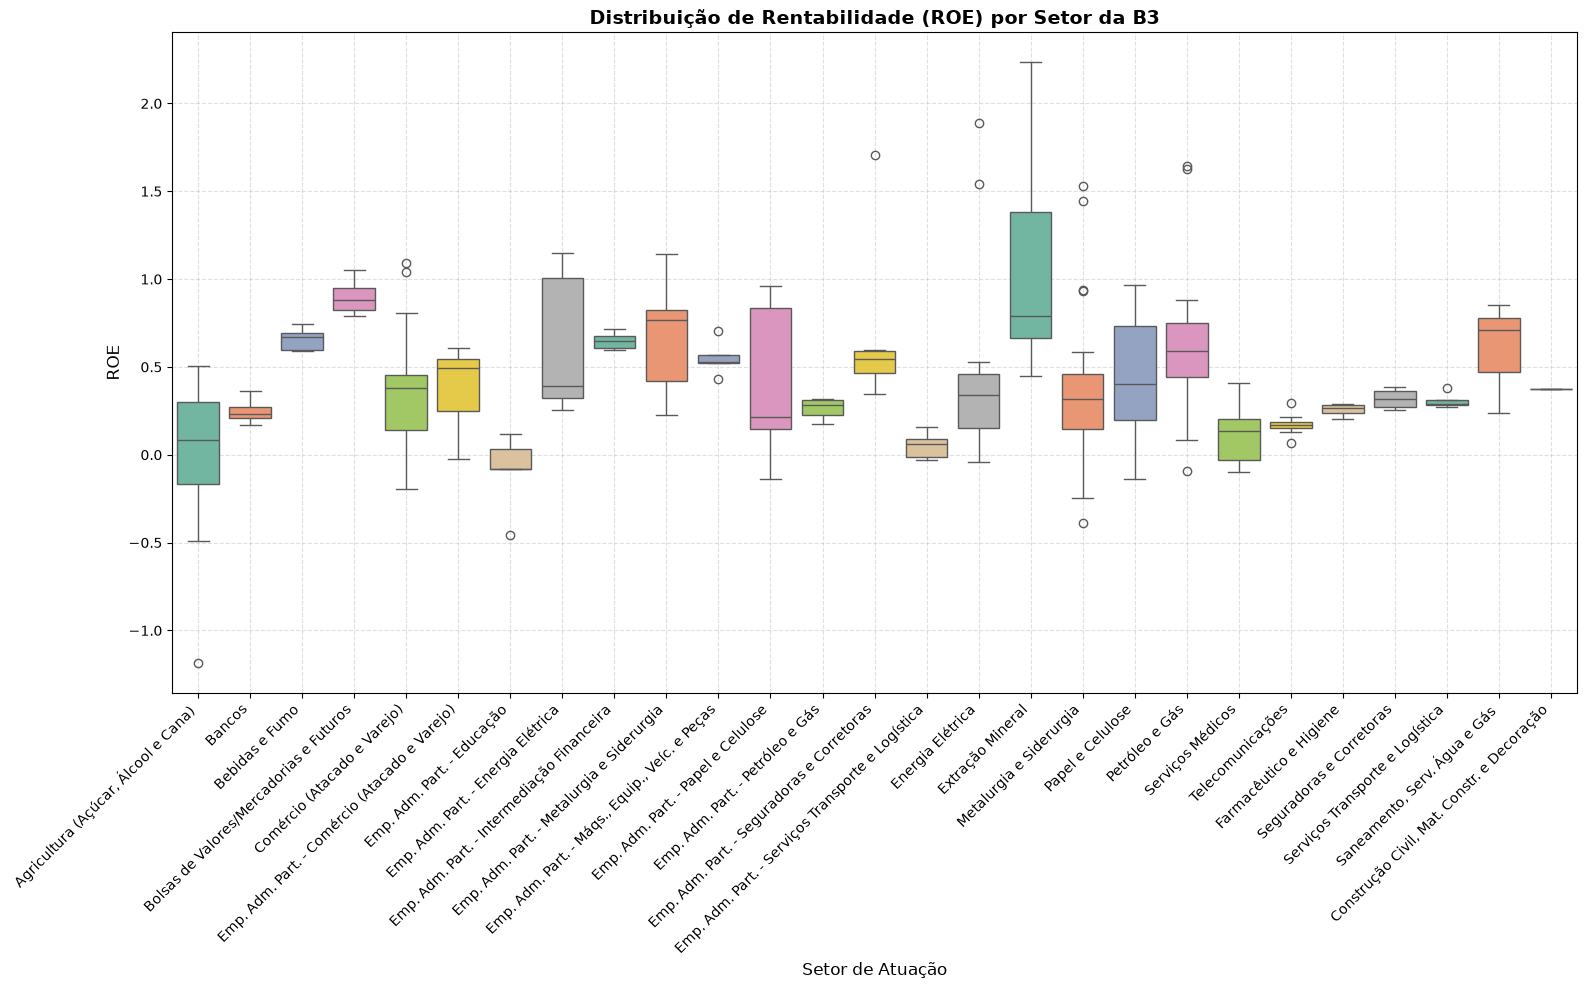

In [34]:
# Boxplot: Distribuição de ROE por Setor na B3
plt.figure(figsize=(16,10))
sns.boxplot(data=df_final, x='SETOR', y='ROE', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribuição de Rentabilidade (ROE) por Setor da B3', fontsize=14, fontweight='bold')
plt.xlabel('Setor de Atuação', fontsize=12)
plt.ylabel('ROE', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [35]:
df_final.describe()

,ANO,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
count,235.000000,235.000000,2.350000e+02,235.000000,235,235.000000
mean,2023.174468,45.606212,9.692111e+07,0.407698,2024-03-04 03:03:49,35.320944
min,2021.000000,-36.712334,1.000172e+07,-1.183901,2021-12-31 00:00:00,0.810000
25%,2022.000000,3.318205,1.375334e+07,0.173162,2022-12-31 00:00:00,10.619711
50%,2023.000000,7.347428,2.162109e+07,0.319633,2023-12-31 00:00:00,17.413023
75%,2024.000000,23.101959,4.871682e+07,0.592697,2024-12-31 00:00:00,30.306642
max,2025.000000,1272.896247,2.949567e+09,2.233830,2025-12-31 00:00:00,3078.866455
std,1.386514,144.459633,3.169951e+08,0.412142,NaN,200.170811


In [36]:
df_final['COTACAO_FINAL_ANO'].max()
df_final['TICKER'].value_counts()


TICKER
SUZB3.SA     10
ALOS3.SA      8
CMIG4.SA      8
RAIZ4.SA      8
TIMS3.SA      7
CSAN3.SA      5
BBDC4.SA      5
BBAS3.SA      5
SANB11.SA     5
ABEV3.SA      5
B3SA3.SA      5
VIVA3.SA      5
VBBR3.SA      5
COGN3.SA      5
CPFE3.SA      5
ALUP11.SA     5
ITSA4.SA      5
GOAU4.SA      5
WEGE3.SA      5
UGPA3.SA      5
CXSE3.SA      5
RAIL3.SA      5
EQTL3.SA      5
VALE3.SA      5
MTSA4.SA      5
CSNA3.SA      5
USIM5.SA      5
GGBR4.SA      5
PETR4.SA      5
HAPV3.SA      5
RDOR3.SA      5
VIVT3.SA      5
PRIO3.SA      5
MGLU3.SA      4
CMIN3.SA      4
LREN3.SA      4
ENGI11.SA     4
AURE3.SA      4
ENEV3.SA      4
HYPE3.SA      4
PSSA3.SA      4
RENT3.SA      4
KLBN11.SA     3
SBSP3.SA      3
PCAR3.SA      2
BRSR6.SA      2
EGIE3.SA      2
BRAV3.SA      2
AMER3.SA      1
CYRE3.SA      1
GMAT3.SA      1
BBSE3.SA      1
Name: count, dtype: int64

In [37]:
df_final.loc[df_final['COTACAO_FINAL_ANO'] == df_final['COTACAO_FINAL_ANO'].max()]


,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
10,2021,AMERICANAS S.A. - EM RECUPERAÇÃO JUDICIAL,AMER3.SA,Comércio (Atacado e Varejo),0.666074,15910976.0,0.041863,2021-12-31,3078.866455


In [38]:
# Removendo a Americanas,pois elas faliu, do dataset para evitar distorção de escala por grupamento
df_final = df_final[df_final['TICKER'] != 'AMER3.SA'].copy()


# Verificando novamente as estatísticas
df_final.describe()


,ANO,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
count,234.000000,234.000000,2.340000e+02,234.000000,234,234.000000
mean,2023.183761,45.798264,9.726731e+07,0.409261,2024-03-07 12:30:46,22.314339
min,2021.000000,-36.712334,1.000172e+07,-1.183901,2021-12-31 00:00:00,0.810000
25%,2022.000000,3.355716,1.374468e+07,0.173896,2022-12-31 00:00:00,10.593760
50%,2023.000000,7.357494,2.170218e+07,0.322842,2023-12-31 00:00:00,17.341787
75%,2024.000000,23.148831,4.873676e+07,0.593221,2024-12-31 00:00:00,30.181540
max,2025.000000,1272.896247,2.949567e+09,2.233830,2025-12-31 00:00:00,155.699997
std,1.382134,144.739233,3.176301e+08,0.412326,NaN,17.729397


In [39]:
#Lembrei da Oi que também faliu
df_final= df_final[df_final['TICKER'] != 'OIBR3.SA'].copy()

In [40]:
# 1. Remover duplicidades de TICKER e ANO (mantendo o registro principal)
df_final = df_final.drop_duplicates(subset=['TICKER', 'ANO'], keep='first').copy()

# 2. Conferir a contagem agora (todas terão no máximo 5 registros!)
df_final['TICKER'].value_counts()


TICKER
CSAN3.SA     5
BBDC4.SA     5
BBAS3.SA     5
SANB11.SA    5
ABEV3.SA     5
B3SA3.SA     5
VIVA3.SA     5
VBBR3.SA     5
ALOS3.SA     5
COGN3.SA     5
CPFE3.SA     5
ALUP11.SA    5
ITSA4.SA     5
GOAU4.SA     5
WEGE3.SA     5
SUZB3.SA     5
UGPA3.SA     5
CXSE3.SA     5
RAIL3.SA     5
EQTL3.SA     5
CMIG4.SA     5
VALE3.SA     5
MTSA4.SA     5
CSNA3.SA     5
USIM5.SA     5
GGBR4.SA     5
PETR4.SA     5
HAPV3.SA     5
RDOR3.SA     5
VIVT3.SA     5
TIMS3.SA     5
MGLU3.SA     4
CMIN3.SA     4
RAIZ4.SA     4
LREN3.SA     4
ENGI11.SA    4
AURE3.SA     4
ENEV3.SA     4
HYPE3.SA     4
PSSA3.SA     4
RENT3.SA     4
KLBN11.SA    3
PRIO3.SA     3
SBSP3.SA     3
PCAR3.SA     2
BRSR6.SA     2
EGIE3.SA     2
BRAV3.SA     2
CYRE3.SA     1
GMAT3.SA     1
BBSE3.SA     1
Name: count, dtype: int64

In [41]:
df_final.describe()

,ANO,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
count,215.000000,215.000000,2.150000e+02,215.000000,215,215.000000
mean,2023.153488,49.165432,1.039248e+08,0.416522,2024-02-25 11:09:46,22.119753
min,2021.000000,-36.712334,1.000172e+07,-1.183901,2021-12-31 00:00:00,0.810000
25%,2022.000000,3.362484,1.375334e+07,0.174506,2022-12-31 00:00:00,11.021710
50%,2023.000000,7.776354,2.178327e+07,0.335246,2023-12-31 00:00:00,17.413023
75%,2024.000000,24.348449,5.238983e+07,0.597922,2024-12-31 00:00:00,29.591689
max,2025.000000,1272.896247,2.949567e+09,2.233830,2025-12-31 00:00:00,155.699997
std,1.394138,150.534271,3.305887e+08,0.421074,NaN,17.491752


In [45]:
df_final.loc[df_final['LUCRO_LIQUIDO_BI'] == df_final['LUCRO_LIQUIDO_BI'].max()]



,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO
189,2025,VIVARA PARTICIPAÇÕES S.A.,VIVA3.SA,Comércio (Atacado e Varejo),1272.896247,2.949567e+09,0.431554,2025-12-31,33.240002


In [48]:
# Correção de escala: Vivara e Metisa reportaram em Reais (UNIDADE) e não em Milhares (MIL) na CVM
filtro_unidade = df_final['TICKER'].isin(['VIVA3.SA', 'MTSA4.SA'])
df_final.loc[filtro_unidade, 'LUCRO_LIQUIDO_BI'] = df_final.loc[filtro_unidade, 'LUCRO_LIQUIDO_BI'] / 1000
df_final.loc[filtro_unidade, 'PATRIMONIO_LIQUIDO_BI'] = df_final.loc[filtro_unidade, 'PATRIMONIO_LIQUIDO_BI'] / 1000

# Salvar o arquivo consolidado 100% limpo
df_final.to_csv(r'..\data\processed\dados_consolidados_b3.csv', index=False)
print("Base atualizada e salva com sucesso em data/processed/dados_consolidados_b3.csv!")

Base atualizada e salva com sucesso em data/processed/dados_consolidados_b3.csv!
